# 第 3 天起的流量过程可视化

按场景只绘制初始条件和边界条件。`training_dataset_cache` 已经是原始数据第 3～31 天的缓存，并将时间重编号为 0～28 天，因此这里不再二次截取。

## 1. 导入依赖与设置参数

In [1]:
from pathlib import Path
import importlib
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# 配置支持中文的字体；否则 DejaVu Sans 会把中文显示成方框。
CJK_FONT_CANDIDATES = [
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc',
]
CJK_FONT = next((Path(p) for p in CJK_FONT_CANDIDATES if Path(p).exists()), None)
if CJK_FONT is not None:
    font_manager.fontManager.addfont(str(CJK_FONT))
    rcParams['font.family'] = font_manager.FontProperties(fname=str(CJK_FONT)).get_name()
else:
    print('警告：未找到中文字体，请安装 fonts-noto-cjk 后重启内核。')
rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'training_dataset_cache').exists():
    PROJECT_ROOT = Path('/home/ubuntu/work/wuda_river1d')

START_DAY = 0.0  # 缓存时间；对应原始数据第 3 天
ORIGINAL_START_DAY = 3.0
SPLIT = 'all'       # 'all', 'train' 或 'test'
MAX_SCENARIOS = 0  # 0 表示全部场景
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'flow_process_plots'
DPI = 160

base = importlib.import_module('river1d.021_flow_generalization')
dataset = base.ScenarioDataset(base.cache_directory)
print(f'场景总数: {len(dataset.scenario_files)}')
print(f'输出目录: {OUTPUT_DIR}')

场景总数: 501
输出目录: /home/ubuntu/work/wuda_river1d/outputs/flow_process_plots


## 2. 选择场景并使用缓存的完整时间范围

In [2]:
def scenario_number(path):
    match = re.search(r'S(\d+)', Path(path).name)
    return int(match.group(1)) if match else 10**9

def select_paths(split='all', max_scenarios=0):
    if split == 'train':
        paths = list(dataset.train_files)
    elif split == 'test':
        paths = list(dataset.test_files)
    else:
        paths = list(dataset.scenario_files)
    paths = sorted(paths, key=scenario_number)
    return paths if max_scenarios <= 0 else paths[:max_scenarios]

def crop_from_day(scenario, start_day=3.0):
    time_days = np.asarray(scenario['t'], dtype=float) / 86400.0
    start = int(np.searchsorted(time_days, start_day, side='left'))
    if start >= len(time_days):
        raise ValueError(f'没有第 {start_day:g} 天之后的数据')
    return {
        'time_days': time_days[start:],
        'x_km': np.asarray(scenario['x'], dtype=float) / 1000.0,
        'z': np.asarray(scenario['z'])[start:],
        'q': np.asarray(scenario['q'])[start:],
    }

paths = select_paths(SPLIT, MAX_SCENARIOS)
print(f'待绘制场景数: {len(paths)}')
first = crop_from_day(dataset.load_scenario(paths[0]), START_DAY)
print('缓存时间范围:', first['time_days'][0], '到', first['time_days'][-1], '天')
print(f'缓存模拟起点（原始第 {ORIGINAL_START_DAY:g} 天）: Z({START_DAY:g},x), Q({START_DAY:g},x)')
print('边界条件: 上游 Q(t), 下游 Z(t)')

待绘制场景数: 501
缓存时间范围: 0.0 到 28.0 天
缓存模拟起点（原始第 3 天）: Z(0,x), Q(0,x)
边界条件: 上游 Q(t), 下游 Z(t)


## 3. 定义单个场景绘图函数

每张图只包含四类条件：初始水位、初始流量、上游边界流量和下游边界水位。

In [3]:
def plot_scenario(path, scenario, output_path=None, dpi=160):
    time_days, x_km = scenario['time_days'], scenario['x_km']
    z, q = scenario['z'], scenario['q']
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

    ax = axes[0, 0]
    ax.plot(x_km, z[0], color='tab:green', lw=2)
    ax.set(title=f'初始水位条件 Z(缓存 t={START_DAY:g}, x)，原始第 {ORIGINAL_START_DAY:g} 天', xlabel='距离 x (km)', ylabel='水位 Z')
    ax.grid(alpha=.25)

    ax = axes[0, 1]
    ax.plot(x_km, q[0], color='tab:purple', lw=2)
    ax.set(title=f'初始流量条件 Q(缓存 t={START_DAY:g}, x)，原始第 {ORIGINAL_START_DAY:g} 天', xlabel='距离 x (km)', ylabel='流量 Q')
    ax.grid(alpha=.25)

    ax = axes[1, 0]
    ax.plot(time_days, q[:, 0], color='tab:blue', lw=2)
    ax.set(title=f'上游边界流量 Q(t, x_up)，原始第 {ORIGINAL_START_DAY:g} 天起', xlabel='缓存时间 (day)', ylabel='流量 Q')
    ax.grid(alpha=.25)

    ax = axes[1, 1]
    ax.plot(time_days, z[:, -1], color='tab:orange', lw=2)
    ax.set(title=f'下游边界水位 Z(t, x_down)，原始第 {ORIGINAL_START_DAY:g} 天起', xlabel='缓存时间 (day)', ylabel='水位 Z')
    ax.grid(alpha=.25)

    number = scenario_number(path)
    fig.suptitle(f'S{number:03d} | 原始第 {ORIGINAL_START_DAY:g}～31 天 | 初始/边界条件 | {Path(path).stem}', fontsize=14)
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, bbox_inches='tight')
    return fig

## 4. 先查看一个场景

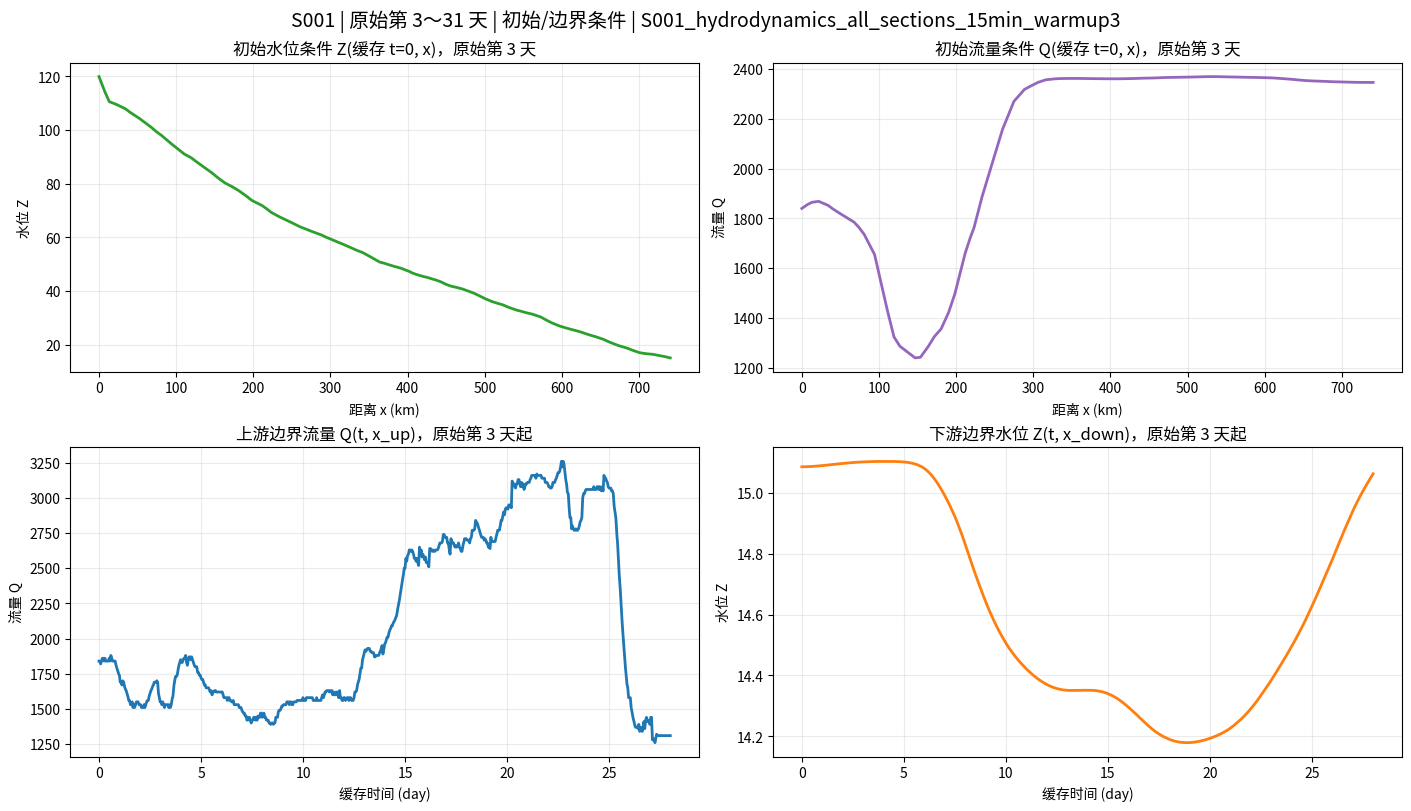

In [4]:
sample_path = paths[0]
sample = crop_from_day(dataset.load_scenario(sample_path), START_DAY)
fig = plot_scenario(sample_path, sample, dpi=DPI)
plt.show()

## 5. 批量保存所有场景图片

In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for i, path in enumerate(paths, 1):
    scenario = crop_from_day(dataset.load_scenario(path), START_DAY)
    output_path = OUTPUT_DIR / f'{Path(path).stem}.png'
    fig = plot_scenario(path, scenario, output_path, DPI)
    plt.close(fig)
    print(f'[{i}/{len(paths)}] {path.name} -> {output_path}')

[1/501] S001_hydrodynamics_all_sections_15min_warmup3.npz -> /home/ubuntu/work/wuda_river1d/outputs/flow_process_plots/S001_hydrodynamics_all_sections_15min_warmup3.png
[2/501] S002_hydrodynamics_all_sections_15min_warmup3.npz -> /home/ubuntu/work/wuda_river1d/outputs/flow_process_plots/S002_hydrodynamics_all_sections_15min_warmup3.png
[3/501] S003_hydrodynamics_all_sections_15min_warmup3.npz -> /home/ubuntu/work/wuda_river1d/outputs/flow_process_plots/S003_hydrodynamics_all_sections_15min_warmup3.png
[4/501] S004_hydrodynamics_all_sections_15min_warmup3.npz -> /home/ubuntu/work/wuda_river1d/outputs/flow_process_plots/S004_hydrodynamics_all_sections_15min_warmup3.png
[5/501] S005_hydrodynamics_all_sections_15min_warmup3.npz -> /home/ubuntu/work/wuda_river1d/outputs/flow_process_plots/S005_hydrodynamics_all_sections_15min_warmup3.png
[6/501] S006_hydrodynamics_all_sections_15min_warmup3.npz -> /home/ubuntu/work/wuda_river1d/outputs/flow_process_plots/S006_hydrodynamics_all_sections_15mi